In [ ]:
import pandas as pd
import numpy as np

In [65]:
df = pd.read_csv("../datasets/risk_behavior.csv")
df

,Age,Gender,education_level,Prison_type,Prison_security_level,Block_security_level,Incidents_count,Violent_incident_count,escape_incident_count,days_since_last_incidence,total_disciplinary_days,Risk Behaviour
0,58,Male,Primary,Maximum Security,High,High,6,0,1,52,19,Medium
1,61,Male,Secondary,Juvenile,Medium,High,3,0,0,119,4,Low
2,50,Male,Secondary,Remand,Medium,Medium,3,0,0,229,9,Low
3,55,Female,Secondary,Maximum Security,High,High,5,1,0,216,12,Medium
4,39,Male,Secondary,Maximum Security,High,High,8,1,0,194,20,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,50,Male,Primary,Minimum Security,Low,Low,1,0,0,48,5,Low
19996,50,Female,Primary,Women's,Low,Low,1,0,0,242,0,Low
19997,50,Female,Preparatory,Women's,Medium,Low,4,0,0,197,13,Low
19998,24,Male,Secondary,Maximum Security,High,High,10,2,3,147,29,High


In [66]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Age                        20000 non-null  int64 
 1   Gender                     20000 non-null  object
 2   education_level            20000 non-null  object
 3   Prison_type                20000 non-null  object
 4   Prison_security_level      20000 non-null  object
 5   Block_security_level       20000 non-null  object
 6   Incidents_count            20000 non-null  int64 
 7   Violent_incident_count     20000 non-null  int64 
 8   escape_incident_count      20000 non-null  int64 
 9   days_since_last_incidence  20000 non-null  int64 
 10  total_disciplinary_days    20000 non-null  int64 
 11  Risk Behaviour             20000 non-null  object
dtypes: int64(6), object(6)
memory usage: 1.8+ MB


,Age,Incidents_count,Violent_incident_count,escape_incident_count,days_since_last_incidence,total_disciplinary_days
count,20000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.000000
mean,41.451000,5.42405,0.790550,0.49125,183.557300,15.930650
std,13.888947,3.34142,1.136814,0.81973,106.394484,10.936307
min,18.000000,1.00000,0.000000,0.00000,0.000000,0.000000
25%,29.000000,3.00000,0.000000,0.00000,90.000000,7.000000
50%,42.000000,5.00000,0.000000,0.00000,184.000000,15.000000
75%,54.000000,8.00000,1.000000,1.00000,276.250000,23.000000
max,65.000000,21.00000,8.000000,5.00000,365.000000,70.000000


In [67]:
df.duplicated().sum()

np.int64(2)

In [68]:
df.drop_duplicates(inplace=True)

In [69]:
df["Risk Behaviour"].value_counts()

Risk Behaviour
Low       8247
Medium    7355
High      4396
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

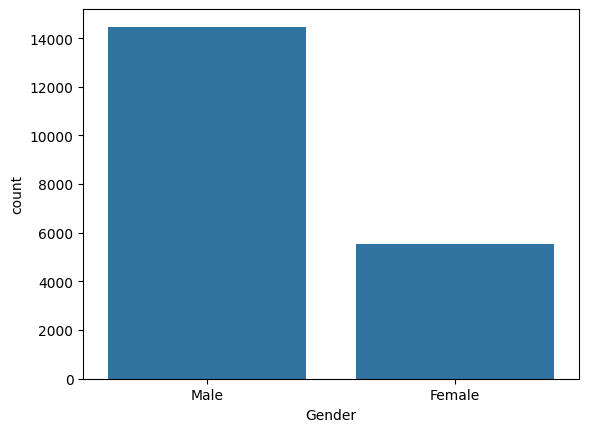

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data=df, x="Gender")

<Axes: xlabel='Risk Behaviour', ylabel='count'>

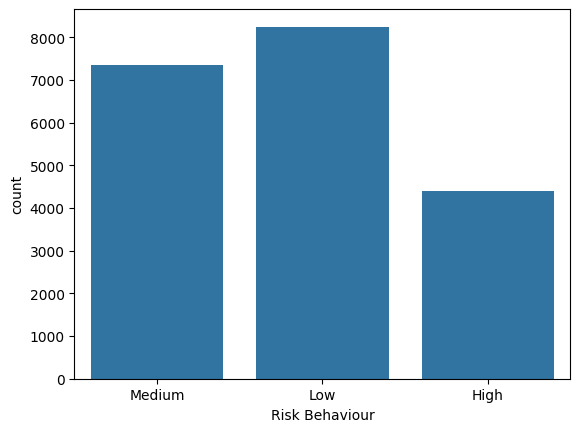

In [71]:
sns.countplot(data=df, x="Risk Behaviour")

<Axes: >

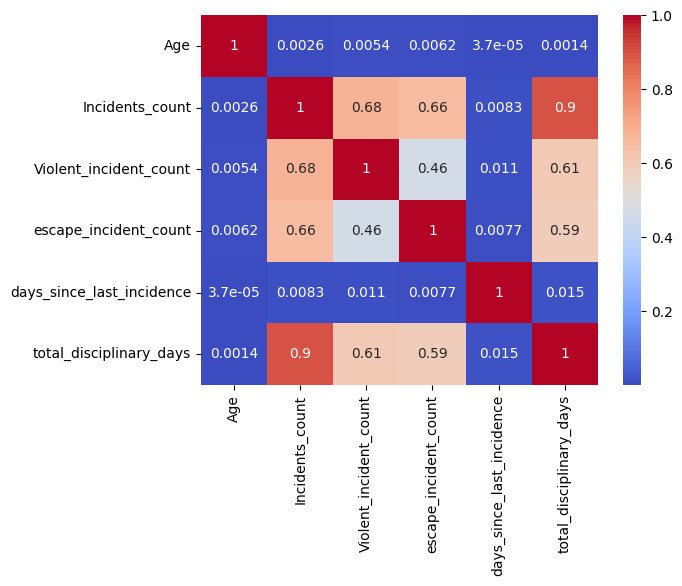

In [72]:
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

In [73]:
# encoding categorical variables
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Risk Behaviour'] = label_encoder.fit_transform(df['Risk Behaviour'])

In [74]:
df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "education_level",
        "Prison_type",
        "Prison_security_level",
        "Block_security_level"
    ],
    drop_first=True
)

In [75]:
X = df.drop("Risk Behaviour", axis=1)

y = df["Risk Behaviour"]

In [76]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [77]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# train and evaluate models
from sklearn.metrics import accuracy_score

scaled_models = [
    "Logistic Regression",
    "Support Vector Machine",
    "K-Nearest Neighbors"
]

results = []

for name, model in models.items():
    print("-"*50)
    print(name)

    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
    else:
        model.fit(X_train, y_train)

    if name in scaled_models:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

    print(f"Accuracy: {acc}")

--------------------------------------------------
Logistic Regression
Accuracy: 0.95025
--------------------------------------------------
Naive Bayes
Accuracy: 0.77325
--------------------------------------------------
K-Nearest Neighbors
Accuracy: 0.8955
--------------------------------------------------
Support Vector Machine
Accuracy: 0.964
--------------------------------------------------
Decision Tree
Accuracy: 0.9385
--------------------------------------------------
XGBoost
Accuracy: 0.97975
--------------------------------------------------
Random Forest
Accuracy: 0.957
